# Guardian Topic Relevance Rank Curve Exploration

This notebook explores how **raw topic-relevance scores** change as you go down the ranked retrieval list for a query.

What it covers:
- run raw retrieval for one query using both `tfidf` and `svd`
- inspect ranked score tables with raw scores, percent-of-top, and adjacent-rank drops
- plot rank-curve falloff for both retrieval models on separate axes
- plot the full raw-score distribution for both retrieval models on separate axes
- optionally export the selected model's ranked score table to CSV

Notes:
- this notebook uses the backend retrieval functions already built in the repo
- the first import of `backend.app` may take a little time because it initializes the backend environment
- **raw scores are not directly comparable across retrieval models**; the separate axes below keep each model readable while the percent-of-top and ECDF views still help compare shape
- the full-distribution plots below use **all positively scored articles returned by each retrieval model for the query**, not just the top `TOP_N` slice


In [12]:
from pathlib import Path
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = next(
    (
        path
        for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
        if (path / 'backend').exists() and (path / 'data').exists()
    ),
    Path.cwd().resolve(),
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from backend.app import app
from backend.services.retrieval_service import (
    DEFAULT_RETRIEVAL_MODEL,
    SUPPORTED_RETRIEVAL_MODELS,
    retrieval_search,
)
from backend.text_processing.search_helpers import build_retrieval_processor

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 140)
PROJECT_ROOT


PosixPath('/Users/stevenzhou/Desktop/StevenZhou/Undergraduate/INFO4300/hearhear')

In [13]:
MODEL_COLORS = {
    'tfidf': '#185abc',
    'svd': '#8a5c00',
}

MODEL_LABELS = {
    'tfidf': 'TF-IDF',
    'svd': 'Truncated SVD',
}


def slugify_text(value, max_length=60):
    text = re.sub(r'[^a-zA-Z0-9]+', '-', str(value).strip().lower()).strip('-')
    return text[:max_length] or 'query'


def normalize_model_list(models):
    resolved = []
    for model in list(models or SUPPORTED_RETRIEVAL_MODELS):
        text = str(model).strip().lower()
        if text in SUPPORTED_RETRIEVAL_MODELS and text not in resolved:
            resolved.append(text)
    return resolved or list(SUPPORTED_RETRIEVAL_MODELS)


def topic_relevance_frame(query, retrieval_model=DEFAULT_RETRIEVAL_MODEL, top_n=100):
    resolved_query = str(query or '').strip()
    if len(resolved_query) < 3:
        return pd.DataFrame()

    with app.app_context():
        matches = retrieval_search(
            resolved_query,
            top_n=top_n,
            retrieval_model=retrieval_model,
        )

    frame = pd.DataFrame(matches)
    if frame.empty:
        return frame

    frame = frame.copy()
    frame.insert(0, 'rank', np.arange(1, len(frame) + 1))
    frame['raw_topic_relevance'] = pd.to_numeric(frame['score'], errors='coerce')
    frame = frame[frame['raw_topic_relevance'].notna()].copy()
    if frame.empty:
        return frame

    top_score = float(frame['raw_topic_relevance'].iloc[0])
    previous_scores = frame['raw_topic_relevance'].shift(1)
    frame['pct_of_top_score'] = np.where(
        top_score > 0,
        frame['raw_topic_relevance'] / top_score,
        np.nan,
    )
    frame['drop_from_previous'] = previous_scores - frame['raw_topic_relevance']
    frame['ratio_to_previous'] = np.where(
        previous_scores > 0,
        frame['raw_topic_relevance'] / previous_scores,
        np.nan,
    )
    frame['drop_from_top'] = top_score - frame['raw_topic_relevance']
    frame['retrieval_model'] = retrieval_model

    ordered_columns = [
        'rank',
        'raw_topic_relevance',
        'pct_of_top_score',
        'drop_from_previous',
        'ratio_to_previous',
        'drop_from_top',
        'title',
        'year',
        'author_display',
        'id',
        'url',
        'retrieval_model',
    ]
    remaining_columns = [column for column in frame.columns if column not in ordered_columns]
    return frame[[column for column in ordered_columns if column in frame.columns] + remaining_columns]


def build_topic_relevance_frames_by_model(query, models=None, top_n=100):
    frames = {}
    for model in normalize_model_list(models):
        frame = topic_relevance_frame(query, retrieval_model=model, top_n=top_n)
        if not frame.empty:
            frames[model] = frame
    return frames


def full_topic_score_distribution_frame(query, retrieval_model=DEFAULT_RETRIEVAL_MODEL):
    resolved_query = str(query or '').strip()
    if len(resolved_query) < 3:
        return pd.DataFrame()

    with app.app_context():
        processor = build_retrieval_processor(retrieval_model=retrieval_model)
        ranked = processor.search(
            resolved_query,
            top_n=None,
            return_articles=False,
        )

    if not ranked:
        return pd.DataFrame(columns=['rank', 'doc_id', 'raw_topic_relevance', 'pct_of_top_score'])

    frame = pd.DataFrame(ranked, columns=['doc_id', 'raw_topic_relevance'])
    frame.insert(0, 'rank', np.arange(1, len(frame) + 1))
    frame['raw_topic_relevance'] = pd.to_numeric(frame['raw_topic_relevance'], errors='coerce')
    frame = frame[frame['raw_topic_relevance'].notna()].copy()
    if frame.empty:
        return frame

    top_score = float(frame['raw_topic_relevance'].iloc[0])
    frame['pct_of_top_score'] = np.where(
        top_score > 0,
        frame['raw_topic_relevance'] / top_score,
        np.nan,
    )
    frame['log10_raw_topic_relevance'] = np.log10(frame['raw_topic_relevance'])
    frame['retrieval_model'] = retrieval_model
    return frame


def build_full_topic_score_distribution_frames_by_model(query, models=None):
    frames = {}
    for model in normalize_model_list(models):
        frame = full_topic_score_distribution_frame(query, retrieval_model=model)
        if not frame.empty:
            frames[model] = frame
    return frames


def plot_topic_relevance_curve_comparison(frames_by_model, query):
    if not frames_by_model:
        print('No positive-scoring results were returned for this query.')
        return

    ordered_models = list(frames_by_model.keys())
    figure, axes = plt.subplots(
        len(ordered_models),
        3,
        figsize=(18, max(4.8, 4.2 * len(ordered_models))),
        squeeze=False,
    )

    for row_index, model in enumerate(ordered_models):
        frame = frames_by_model[model]
        color = MODEL_COLORS.get(model, None)
        label = MODEL_LABELS.get(model, model)
        row_axes = axes[row_index]

        row_axes[0].plot(frame['rank'], frame['raw_topic_relevance'], linewidth=2, color=color)
        row_axes[1].plot(frame['rank'], frame['raw_topic_relevance'], linewidth=2, color=color)
        row_axes[2].plot(frame['rank'], frame['pct_of_top_score'], linewidth=2, color=color)

        row_axes[0].set_title(f'{label}: raw topic relevance by rank')
        row_axes[0].set_xlabel('Rank')
        row_axes[0].set_ylabel('Raw score')

        row_axes[1].set_yscale('log')
        row_axes[1].set_title(f'{label}: raw topic relevance by rank (log scale)')
        row_axes[1].set_xlabel('Rank')
        row_axes[1].set_ylabel('Raw score (log)')

        row_axes[2].set_title(f'{label}: percent of top score by rank')
        row_axes[2].set_xlabel('Rank')
        row_axes[2].set_ylabel('Score / top score')
        row_axes[2].set_ylim(0, 1.05)

        max_rank = len(frame)
        for axis in row_axes:
            for cutoff in (10, 20, 50, 100):
                if cutoff <= max_rank:
                    axis.axvline(cutoff, color='gray', linestyle=':', linewidth=0.8, alpha=0.8)

    figure.suptitle(f'Topic relevance rank curves for "{query}"', fontsize=14, y=1.02)
    figure.tight_layout()
    plt.show()


def plot_full_topic_score_distribution_comparison(frames_by_model, query):
    if not frames_by_model:
        print('No positive-scoring articles were available for the full distribution plot.')
        return

    ordered_models = list(frames_by_model.keys())
    figure, axes = plt.subplots(
        len(ordered_models),
        3,
        figsize=(18, max(4.8, 4.2 * len(ordered_models))),
        squeeze=False,
    )

    for row_index, model in enumerate(ordered_models):
        frame = frames_by_model[model]
        color = MODEL_COLORS.get(model, None)
        label = MODEL_LABELS.get(model, model)
        sorted_scores = np.sort(frame['raw_topic_relevance'].to_numpy())
        ecdf = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)
        row_axes = axes[row_index]

        row_axes[0].hist(
            frame['raw_topic_relevance'],
            bins=50,
            color=color,
            alpha=0.82,
            edgecolor='white',
        )
        row_axes[1].hist(
            frame['log10_raw_topic_relevance'],
            bins=50,
            color=color,
            alpha=0.82,
            edgecolor='white',
        )
        row_axes[2].plot(sorted_scores, ecdf, color=color, linewidth=2)

        row_axes[0].set_title(f'{label}: histogram of raw topic relevance')
        row_axes[0].set_xlabel('Raw score')
        row_axes[0].set_ylabel('Article count')

        row_axes[1].set_title(f'{label}: histogram of log10 raw topic relevance')
        row_axes[1].set_xlabel('log10(raw score)')
        row_axes[1].set_ylabel('Article count')

        row_axes[2].set_title(f'{label}: ECDF of raw topic relevance')
        row_axes[2].set_xlabel('Raw score')
        row_axes[2].set_ylabel('Fraction of positively scored articles')
        row_axes[2].set_ylim(0, 1.02)

    figure.suptitle(f'Full positive-score distributions for "{query}"', fontsize=14, y=1.02)
    figure.tight_layout()
    plt.show()

def export_topic_relevance_frame(frame, query, retrieval_model, top_n):
    export_dir = PROJECT_ROOT / 'data' / 'processed' / 'analysis_exports'
    export_dir.mkdir(parents=True, exist_ok=True)
    export_path = export_dir / f'{retrieval_model}_topic_relevance_{slugify_text(query)}_top{top_n}.csv'
    frame.to_csv(export_path, index=False)
    return export_path


In [24]:
QUERY = 'free buses'
GRAPH_MODELS = ['tfidf', 'svd']
DETAIL_MODEL = DEFAULT_RETRIEVAL_MODEL
TOP_N = 100
EXPORT_RESULTS = False

print(f'QUERY: {QUERY}')
print(f'GRAPH_MODELS: {GRAPH_MODELS}')
print(f'DETAIL_MODEL: {DETAIL_MODEL}')
print(f'TOP_N: {TOP_N}')


QUERY: free buses
GRAPH_MODELS: ['tfidf', 'svd']
DETAIL_MODEL: svd
TOP_N: 100


In [25]:
topic_scores_by_model = build_topic_relevance_frames_by_model(
    QUERY,
    models=GRAPH_MODELS,
    top_n=TOP_N,
)

rank_curve_summary_rows = []
for model, frame in topic_scores_by_model.items():
    rank_curve_summary_rows.append({
        'retrieval_model': model,
        'results_in_top_n': len(frame),
        'top_score': frame['raw_topic_relevance'].max(),
        'score_at_rank_10': frame['raw_topic_relevance'].iloc[min(9, len(frame) - 1)] if len(frame) >= 1 else np.nan,
        'score_at_rank_50': frame['raw_topic_relevance'].iloc[min(49, len(frame) - 1)] if len(frame) >= 1 else np.nan,
        'pct_of_top_at_rank_10': frame['pct_of_top_score'].iloc[min(9, len(frame) - 1)] if len(frame) >= 1 else np.nan,
        'pct_of_top_at_rank_50': frame['pct_of_top_score'].iloc[min(49, len(frame) - 1)] if len(frame) >= 1 else np.nan,
    })

rank_curve_summary_df = pd.DataFrame(rank_curve_summary_rows)
rank_curve_summary_df


2026-04-13 14:14:57,784 INFO ts_utc='2026-04-13T18:14:57.784195+00:00' event='retrieval_search.start' rss_mb=974.4 retrieval_model='tfidf' query_chars=10 top_n=100
2026-04-13 14:14:57,804 INFO ts_utc='2026-04-13T18:14:57.804890+00:00' event='retrieval_processor.cache_hit' rss_mb=974.4 retrieval_model='tfidf' doc_count=66331
2026-04-13 14:14:57,805 INFO ts_utc='2026-04-13T18:14:57.805296+00:00' event='postings_search.query_vector_start' rss_mb=974.4 query_chars=10 top_n=100 n_docs=66331 n_terms=82749
2026-04-13 14:14:57,806 INFO ts_utc='2026-04-13T18:14:57.806002+00:00' event='postings_search.query_vector_done' rss_mb=974.4 query_term_count=2
2026-04-13 14:14:57,806 INFO ts_utc='2026-04-13T18:14:57.806428+00:00' event='postings_search.term_progress' rss_mb=974.4 term_index=1 term_total=2 posting_count=656
2026-04-13 14:14:57,806 INFO ts_utc='2026-04-13T18:14:57.806782+00:00' event='postings_search.term_progress' rss_mb=974.5 term_index=2 term_total=2 posting_count=12694
2026-04-13 14:14

,retrieval_model,results_in_top_n,top_score,score_at_rank_10,score_at_rank_50,pct_of_top_at_rank_10,pct_of_top_at_rank_50
0,tfidf,100,0.500824,0.300364,0.117231,0.599739,0.234076
1,svd,100,0.649112,0.599259,0.540555,0.923199,0.832761


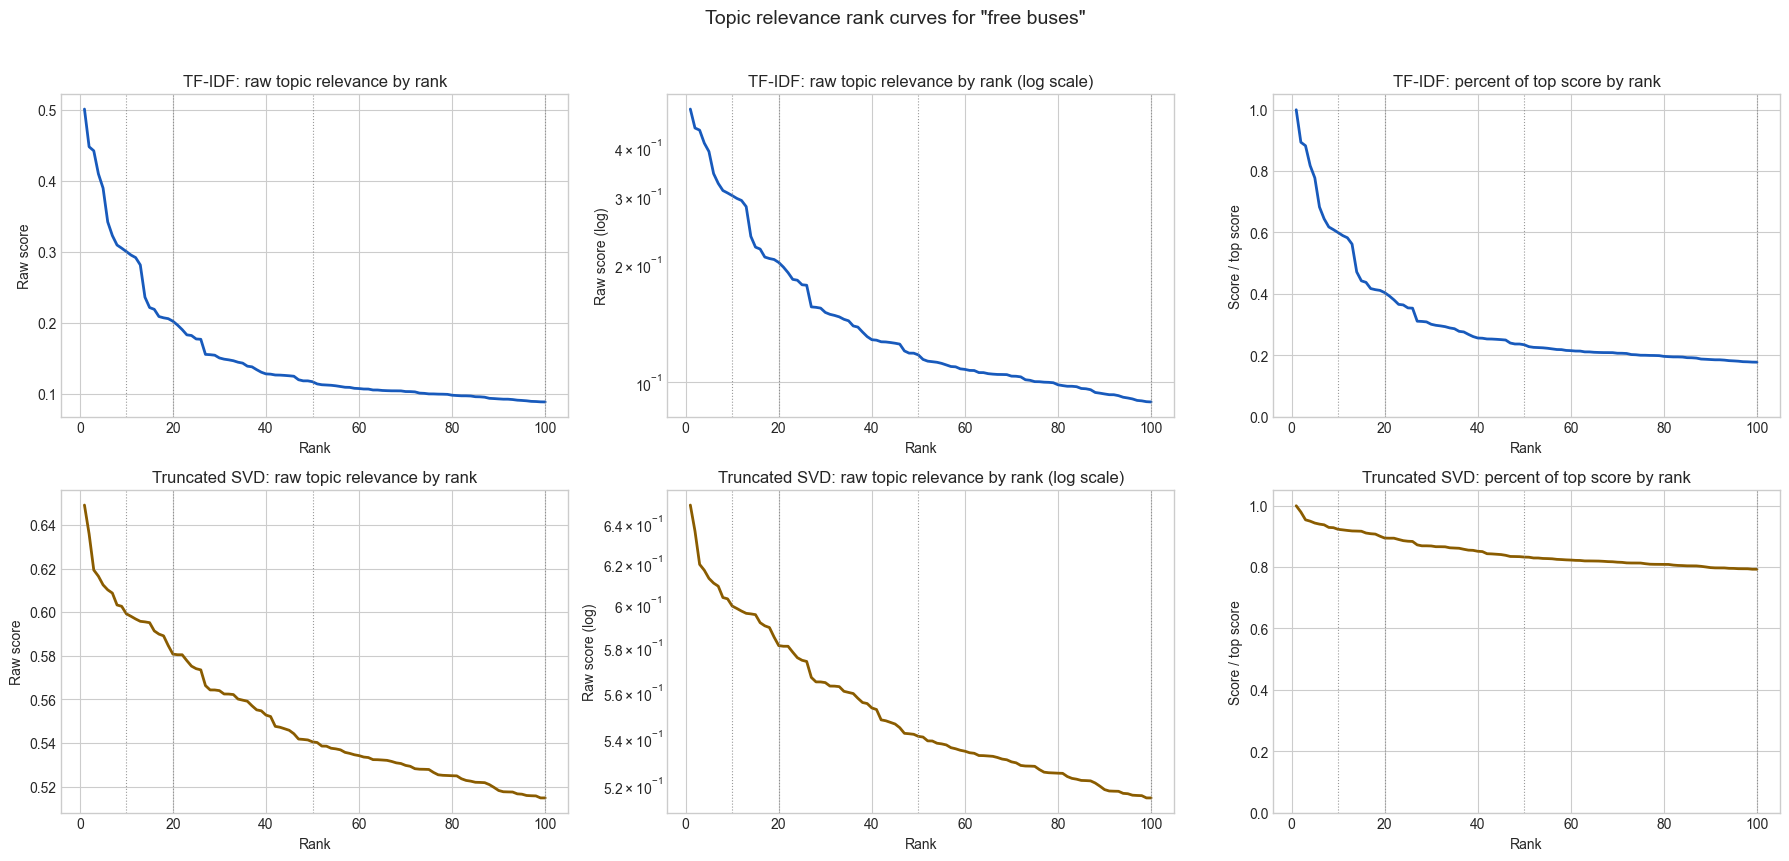

In [27]:
plot_topic_relevance_curve_comparison(
    topic_scores_by_model,
    query=QUERY,
)


In [29]:
all_topic_scores_by_model = build_full_topic_score_distribution_frames_by_model(
    QUERY,
    models=GRAPH_MODELS,
)

distribution_summary_rows = []
for model, frame in all_topic_scores_by_model.items():
    distribution_summary_rows.append({
        'retrieval_model': model,
        'positively_scored_articles': len(frame),
        'top_score': frame['raw_topic_relevance'].max(),
        'median_score': frame['raw_topic_relevance'].median(),
        'p90_score': frame['raw_topic_relevance'].quantile(0.90),
        'p99_score': frame['raw_topic_relevance'].quantile(0.99),
        'minimum_positive_score': frame['raw_topic_relevance'].min(),
    })

distribution_summary_df = pd.DataFrame(distribution_summary_rows)
distribution_summary_df


2026-04-13 14:15:09,460 INFO ts_utc='2026-04-13T18:15:09.460221+00:00' event='retrieval_processor.cache_hit' rss_mb=1010.4 retrieval_model='tfidf' doc_count=66331
2026-04-13 14:15:09,460 INFO ts_utc='2026-04-13T18:15:09.460632+00:00' event='postings_search.query_vector_start' rss_mb=1010.4 query_chars=10 top_n=66331 n_docs=66331 n_terms=82749
2026-04-13 14:15:09,461 INFO ts_utc='2026-04-13T18:15:09.461561+00:00' event='postings_search.query_vector_done' rss_mb=1010.4 query_term_count=2
2026-04-13 14:15:09,462 INFO ts_utc='2026-04-13T18:15:09.462001+00:00' event='postings_search.term_progress' rss_mb=1010.4 term_index=1 term_total=2 posting_count=656
2026-04-13 14:15:09,462 INFO ts_utc='2026-04-13T18:15:09.462673+00:00' event='postings_search.term_progress' rss_mb=1010.4 term_index=2 term_total=2 posting_count=12694
2026-04-13 14:15:09,464 INFO ts_utc='2026-04-13T18:15:09.463759+00:00' event='postings_search.topk_select_start' rss_mb=1010.4 candidate_count=13193
2026-04-13 14:15:09,465 

,retrieval_model,positively_scored_articles,top_score,median_score,p90_score,p99_score,minimum_positive_score
0,tfidf,13193,0.500824,0.010058,0.029924,0.079004,0.001690
1,svd,53687,0.649112,0.063517,0.158983,0.363789,0.000006


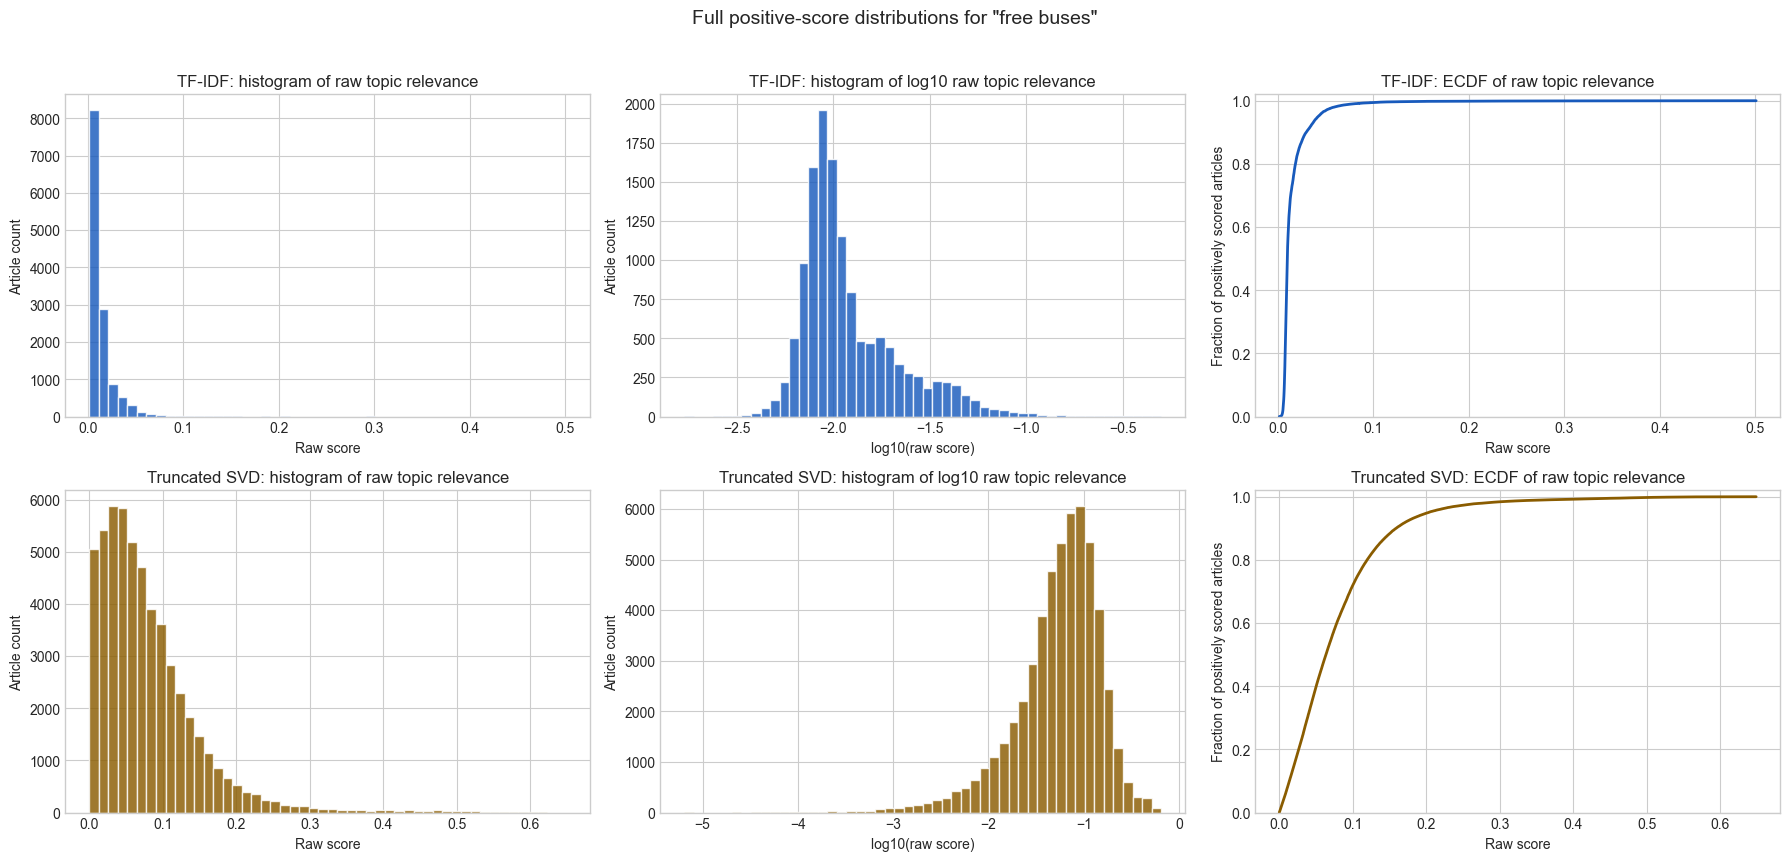

In [30]:
plot_full_topic_score_distribution_comparison(
    all_topic_scores_by_model,
    query=QUERY,
)


In [31]:
topic_scores_df = topic_scores_by_model.get(DETAIL_MODEL, pd.DataFrame())
all_topic_scores_df = all_topic_scores_by_model.get(DETAIL_MODEL, pd.DataFrame())

print(f'Detailed tables below use: {DETAIL_MODEL}')
print(f'Top-N ranked rows available: {len(topic_scores_df):,}')
print(f'All positive-scoring rows available: {len(all_topic_scores_df):,}')

topic_scores_df.head(15)


Detailed tables below use: svd
Top-N ranked rows available: 100
All positive-scoring rows available: 53,687


,rank,raw_topic_relevance,pct_of_top_score,drop_from_previous,ratio_to_previous,drop_from_top,title,year,author_display,id,...,date,authors,author_raw,n_contributors,keywords,score,svd_chart_dimensions,svd_dimensions,svd_positive_dimensions,svd_negative_dimensions
0,1,0.649112,1.000000,NaN,NaN,0.000000,Young people deserve free bus passes,2018,Polly Toynbee,commentisfree/2018/apr/12/young-people-free-bus-passes-labour,...,2018-04-12T11:17:23,[Polly Toynbee],Polly Toynbee,1,"[Bus fares, Money, Consumer affairs, Transport, Transport policy, Young people, Society, UK news, Public services policy, Politics, Loca...",0.649112,"[{'dimension_index': 0, 'dimension_label': 1, 'value': 0.4946754276752472, 'magnitude': 0.4946754276752472, 'pole': 'positive', 'label_t...","[{'dimension_index': 0, 'dimension_label': 1, 'value': 0.4946754276752472, 'magnitude': 0.4946754276752472, 'pole': 'positive', 'label_t...","[{'dimension_index': 0, 'dimension_label': 1, 'value': 0.4946754276752472, 'magnitude': 0.4946754276752472, 'pole': 'positive', 'label_t...","[{'dimension_index': 2, 'dimension_label': 3, 'value': -0.22418007254600525, 'magnitude': 0.22418007254600525, 'pole': 'negative', 'labe..."
1,2,0.635874,0.979607,0.013237,0.979607,0.013237,What we misunderstand in the debate over free speech,2025,Avram Alpert,commentisfree/2025/oct/23/free-speech-free-thought,...,2025-10-23T12:00:38,[Avram Alpert],Avram Alpert,1,"[Freedom of speech, Censorship, Philosophy, US politics, US news]",0.635874,"[{'dimension_index': 0, 'dimension_label': 1, 'value': 0.4158872067928314, 'magnitude': 0.4158872067928314, 'pole': 'positive', 'label_t...","[{'dimension_index': 0, 'dimension_label': 1, 'value': 0.4158872067928314, 'magnitude': 0.4158872067928314, 'pole': 'positive', 'label_t...","[{'dimension_index': 0, 'dimension_label': 1, 'value': 0.4158872067928314, 'magnitude': 0.4158872067928314, 'pole': 'positive', 'label_t...","[{'dimension_index': 13, 'dimension_label': 14, 'value': -0.247738316655159, 'magnitude': 0.247738316655159, 'pole': 'negative', 'label_..."
2,3,0.619345,0.954142,0.016529,0.974005,0.029767,Hate speech leads to violence. Why would liberals defend it?,2018,Nesrine Malik,commentisfree/2018/mar/22/hate-speech-violence-liberals-rightwing-extremists,...,2018-03-22T06:00:17,[Nesrine Malik],Nesrine Malik,1,"[Freedom of speech, The far right, World news, Society, Politics, UK news]",0.619345,"[{'dimension_index': 0, 'dimension_label': 1, 'value': 0.4082457721233368, 'magnitude': 0.4082457721233368, 'pole': 'positive', 'label_t...","[{'dimension_index': 0, 'dimension_label': 1, 'value': 0.4082457721233368, 'magnitude': 0.4082457721233368, 'pole': 'positive', 'label_t...","[{'dimension_index': 0, 'dimension_label': 1, 'value': 0.4082457721233368, 'magnitude': 0.4082457721233368, 'pole': 'positive', 'label_t...","[{'dimension_index': 34, 'dimension_label': 35, 'value': -0.20308737456798553, 'magnitude': 0.20308737456798553, 'pole': 'negative', 'la..."
3,4,0.616488,0.949742,0.002857,0.995388,0.032623,Free speech is at the core of the left-right divide. But what are we fighting over?,2017,Jason Wilson,commentisfree/2017/jun/05/free-speech-is-at-the-core-of-the-left-right-divide-but-what-are-we-fighting-over,...,2017-06-05T02:27:21,[Jason Wilson],Jason Wilson,1,"[Portland, The far right, US news, World news, Protest]",0.616488,"[{'dimension_index': 0, 'dimension_label': 1, 'value': 0.4068407714366913, 'magnitude': 0.4068407714366913, 'pole': 'positive', 'label_t...","[{'dimension_index': 0, 'dimension_label': 1, 'value': 0.4068407714366913, 'magnitude': 0.4068407714366913, 'pole': 'positive', 'label_t...","[{'dimension_index': 0, 'dimension_label': 1, 'value': 0.4068407714366913, 'magnitude': 0.4068407714366913, 'pole': 'positive', 'label_t...","[{'dimension_index': 34, 'dimension_label': 35, 'value': -0.22290685772895813, 'magnitude': 0.22290685772895813, 'pole': 'negative', 'la..."
4,5,0.612516,0.943621,0.003973,0.993556,0.036596,Free calls to Santa 

In [20]:
selected_ranks = [rank for rank in (1, 5, 10, 20, 50, 100) if rank <= len(topic_scores_df)]
rank_checkpoints_df = topic_scores_df.loc[
    topic_scores_df['rank'].isin(selected_ranks),
    [
        'rank',
        'raw_topic_relevance',
        'pct_of_top_score',
        'drop_from_previous',
        'ratio_to_previous',
        'title',
    ],
]
rank_checkpoints_df


,rank,raw_topic_relevance,pct_of_top_score,drop_from_previous,ratio_to_previous,title
0,1,0.960995,1.000000,NaN,NaN,"Come on, UK weather forecasters – tell it like it is on climate change"
4,5,0.937177,0.975215,0.002842,0.996976,The planet faces a climate emergency – but activists need to strap in for the long haul
9,10,0.922015,0.959438,0.001318,0.998573,The urgency of climate crisis needed robust new language to describe it
19,20,0.902191,0.938810,0.003428,0.996215,Is Jonathan Franzen really asking us to shrug off the destruction of our world?
49,50,0.873402,0.908852,0.002723,0.996892,Brexit has distracted us from the climate disaster awaiting us. Britain must step up
99,100,0.836289,0.870233,0.000250,0.999701,I asked the five candidates about climate in the TV debate. None has a clear plan


In [21]:
largest_drop_df = topic_scores_df.iloc[1:][
    ['rank', 'raw_topic_relevance', 'drop_from_previous', 'ratio_to_previous', 'title']
].nlargest(15, 'drop_from_previous')
largest_drop_df


,rank,raw_topic_relevance,drop_from_previous,ratio_to_previous,title
1,2,0.948443,0.012552,0.986939,Our school climate strikes have been a success and we’re only getting started
7,8,0.924035,0.005975,0.993575,Disempower far-right climate change deniers. Don’t debate with them
2,3,0.943219,0.005224,0.994492,Caring about climate change: it's time to build a bridge between data and emotion
21,22,0.896309,0.005143,0.994295,Donald Trump is using Stalinist tactics to discredit climate science
11,12,0.917575,0.004353,0.995279,Climate change is happening now – here’s eight things we can do to adapt to it
6,7,0.930010,0.003842,0.995885,"Whether you’re a climate ‘doomer’ or ‘appeaser’, it’s best to prepare for the worst"
19,20,0.902191,0.003428,0.996215,Is Jonathan Franzen really asking us to shrug off the destruction of our world?
5,6,0.933852,0.003324,0.996453,In 2019 the public woke up to the climate crisis. When will the politicians? \r\n
17,18,0.908152,0.003238,0.996448,Polling shows that US voters favor climate bills – yet assume fellow Americans don’t
3,4,0.940019,0.003200,0.996607,"After Extinction Rebellion, Australian politicians are on notice – change is coming"


In [22]:
RANK_WINDOW = (1, 25)

topic_scores_df.loc[
    topic_scores_df['rank'].between(RANK_WINDOW[0], RANK_WINDOW[1]),
    ['rank', 'raw_topic_relevance', 'pct_of_top_score', 'drop_from_previous', 'ratio_to_previous', 'title', 'year'],
]


,rank,raw_topic_relevance,pct_of_top_score,drop_from_previous,ratio_to_previous,title,year
0,1,0.960995,1.000000,NaN,NaN,"Come on, UK weather forecasters – tell it like it is on climate change",2019
1,2,0.948443,0.986939,0.012552,0.986939,Our school climate strikes have been a success and we’re only getting started,2019
2,3,0.943219,0.981503,0.005224,0.994492,Caring about climate change: it's time to build a bridge between data and emotion,2017
3,4,0.940019,0.978173,0.003200,0.996607,"After Extinction Rebellion, Australian politicians are on notice – change is coming",2019
4,5,0.937177,0.975215,0.002842,0.996976,The planet faces a climate emergency – but activists need to strap in for the long haul,2019
5,6,0.933852,0.971756,0.003324,0.996453,In 2019 the public woke up to the climate crisis. When will the politicians? \r\n,2019
6,7,0.930010,0.967758,0.003842,0.995885,"Whether you’re a climate ‘doomer’ or ‘appeaser’, it’s best to prepare for the worst",2022
7,8,0.924035,0.961540,0.005975,0.993575,Disempower far-right climate change deniers. Don’t debate with them,2018
8,9,0.923333,0.960809,0.000702,0.999240,Our kids learn their ABCs in school. But why not climate change?,2016
9,10,0.922015,0.959438,0.001318,0.998573,The urgency of climate crisis needed robust new language to describe it,2019


In [23]:
if EXPORT_RESULTS:
    export_path = export_topic_relevance_frame(
        topic_scores_df,
        query=QUERY,
        retrieval_model=DETAIL_MODEL,
        top_n=TOP_N,
    )
    print(export_path)
else:
    preview_path = PROJECT_ROOT / 'data' / 'processed' / 'analysis_exports' / f'{DETAIL_MODEL}_topic_relevance_{slugify_text(QUERY)}_top{TOP_N}.csv'
    print('Set EXPORT_RESULTS = True to write the selected model's ranked score table to:')
    print(preview_path)


SyntaxError: unterminated string literal (detected at line 11) (2375160655.py, line 11)